In [21]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [23]:
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups(subset='train')
texts = data.data[:200]     # keep small
labels = data.target[:200]  # optional (for validation)

In [24]:
from src.preprocessing import clean_text

texts = [clean_text(t) for t in texts]

In [25]:
from src.embedding import get_bert

embeddings = get_bert(texts)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5969.92it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
from src.similarity import compute_similarity

sim = compute_similarity(embeddings)

In [27]:
from src.graph_builder import build_graph

G = build_graph(sim, texts, threshold=0.25)

In [28]:
from src.community import detect_communities

partition = detect_communities(G)

In [29]:
from collections import defaultdict

communities = defaultdict(list)

for node, comm in partition.items():
    communities[comm].append(texts[node])

print("Total communities:", len(communities))

for c, items in communities.items():
    print(f"\nCommunity {c} ({len(items)} nodes):")
    for i in items[:3]:
        print("-", i[:100])

Total communities: 7

Community 0 (35 nodes):
- from lerxstwamumdedu wheres my thing
subject what car is this
nntppostinghost racwamumdedu
organizat
- from irwincmptrclonestarorg irwin arnstein
subject re recommendation on duc
summary whats it worth
d
- from cpkjpvmcclatechedu kevin parker
subject insurance rates on performance cars summary
organizatio

Community 1 (32 nodes):
- from guykuocarsonuwashingtonedu guy kuo
subject si clock poll  final call
summary final call for si 
- from twillisececnpurdueedu thomas e willis
subject pb questions
organization purdue university engin
- from jgreenamber joe green
subject re weitek p 
organization harris computer systems division
lines 

Community 2 (42 nodes):
- from dfovttoulutkovttfi foxvog douglas
subject re rewording the second amendment ideas
organization 
- from davidterminusericssonse david bold
subject re question for those with popular morality
replyto 
- from mathew mathewmantiscouk
subject re political atheists
organization mantis

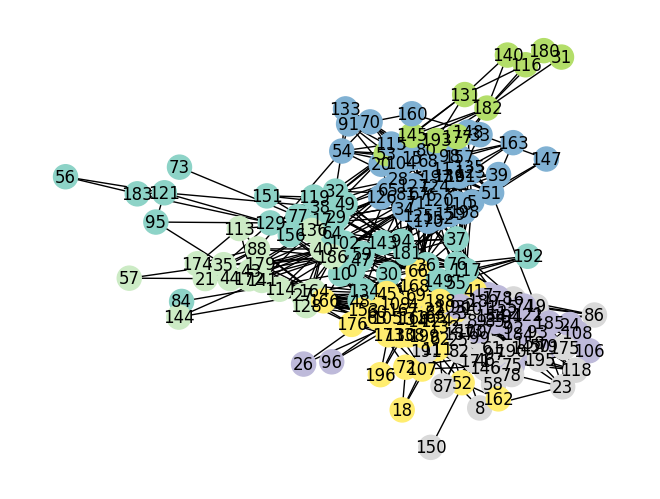

In [30]:
from src.visualize import draw_graph

draw_graph(G, partition)

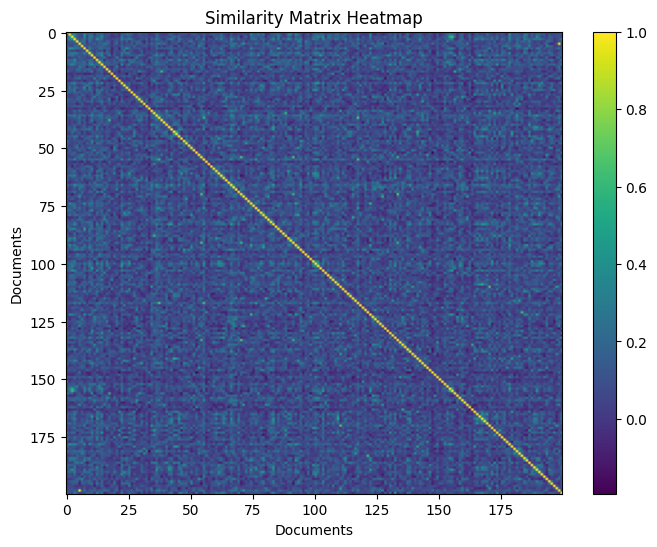

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(sim, aspect='auto')
plt.title("Similarity Matrix Heatmap")
plt.colorbar()
plt.xlabel("Documents")
plt.ylabel("Documents")
plt.show()

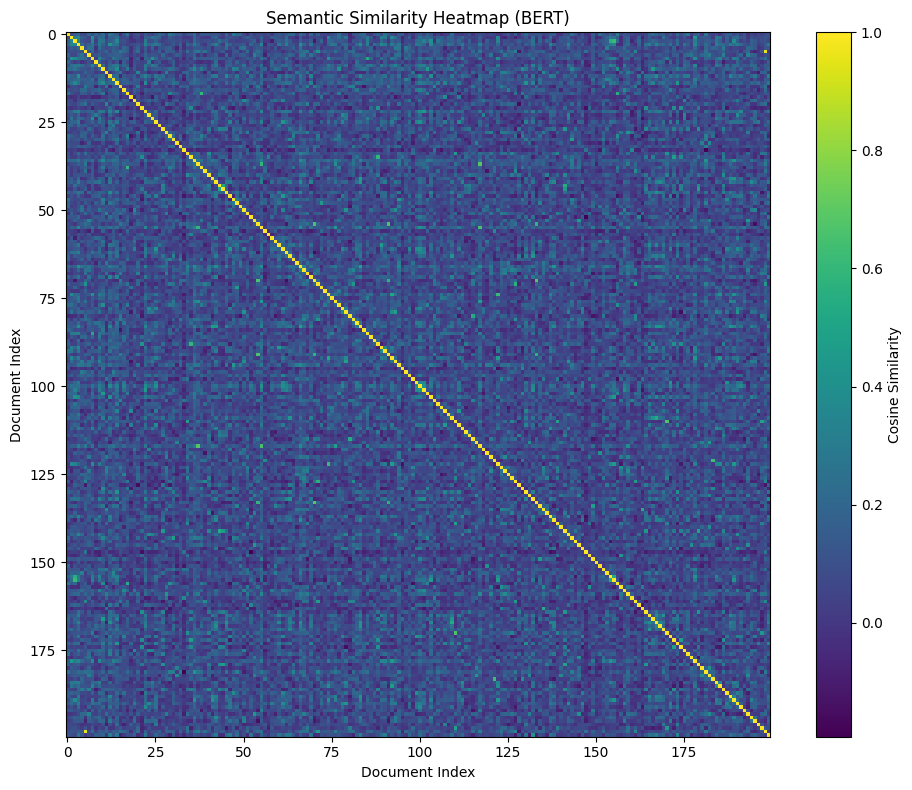

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(sim, cmap='viridis', interpolation='nearest')
plt.title("Semantic Similarity Heatmap (BERT)")
plt.colorbar(label="Cosine Similarity")
plt.xlabel("Document Index")
plt.ylabel("Document Index")
plt.tight_layout()
plt.show()

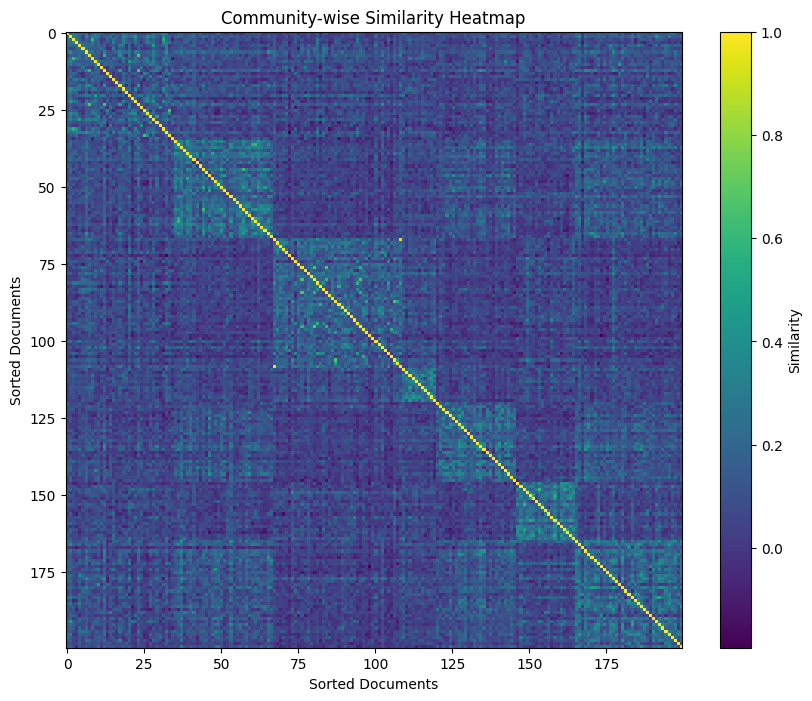

In [33]:
import numpy as np

# Sort nodes by community
sorted_nodes = sorted(partition.keys(), key=lambda x: partition[x])

# Reorder similarity matrix
sim_sorted = sim[np.ix_(sorted_nodes, sorted_nodes)]

plt.figure(figsize=(10, 8))
plt.imshow(sim_sorted, cmap='viridis')
plt.title("Community-wise Similarity Heatmap")
plt.colorbar(label="Similarity")
plt.xlabel("Sorted Documents")
plt.ylabel("Sorted Documents")
plt.show()

In [34]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

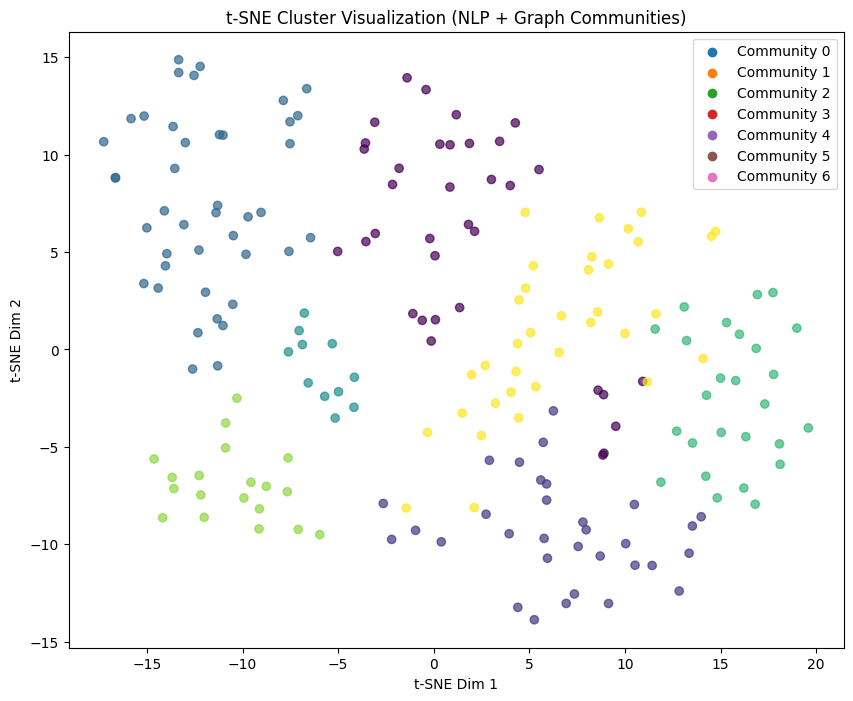

In [36]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

colors = [partition[i] for i in range(len(partition))]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, alpha=0.7)

plt.title("t-SNE Cluster Visualization (NLP + Graph Communities)")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")

# Create legend
unique_labels = list(set(colors))
for label in unique_labels:
    plt.scatter([], [], label=f"Community {label}")

plt.legend()
plt.show()